## First Graph: Defining a State and a Node

### Set the OpenAI API Key as an Environment Variable

### Import Relevant Classes and Functions

In [1]:
!pip install langchain_openai langgraph

In [33]:
!pip install grandalf

In [2]:
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence

### Define the State

In [3]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

In [4]:
state = State(messages = [HumanMessage("Could you tell me a grook by Piet Hein?")])

In [5]:
state["messages"][0].pretty_print()

================================ Human Message =================================

Could you tell me a grook by Piet Hein?


### Define the Nodes

In [7]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("open_xai")
os.environ["OPENAI_API_BASE"] = "https://openrouter.ai/api/v1"

In [10]:
chat = ChatOpenAI(model = "deepseek/deepseek-chat-v3.1:free",
                  temperature = 2,
                  max_tokens = 100,
                  api_key=os.environ["OPENAI_API_KEY"],
                  base_url="https://openrouter.ai/api/v1")

In [11]:
response = chat.invoke(state["messages"])

In [12]:
response.pretty_print()

================================== Ai Message ==================================

Of course! Here is one of Piet Hein's most famous and widely loved grooks:

***

**The Paradoxical Commandments of Life**

*Art is long.*
*And life is short.*
*But long is short*
*for those who die.*
*A perfect song*
*But why abort*
*the efforts mortals make, we try.*
*Whatever goes*
*will slack in pace.*
*Is worth lamenting, I suppose.*
*The world may


In [56]:
def chatbot(state: State) -> State:

    print(f"\n-------> ENTERING chatbot:")

    response = chat.invoke(state["messages"])
    response.pretty_print()

    return State(messages = [response])

In [14]:
chatbot(state)


-------> ENTERING chatbot:
================================== Ai Message ==================================

Of course. One of Piet Hein's most famous and widely appreciated grooks is about a problem and its solution. It perfectly captures his style: simple, elegant, and full of profound, practical wisdom.

Here it is:

> **The Road to Wisdom**
>
> The road to wisdom? — Well, it's plain
> and simple to express:
> Err
> and err
> and err again
> but less
> and less
> and less.

This grook beautifully


{'messages': [AIMessage(content="Of course. One of Piet Hein's most famous and widely appreciated grooks is about a problem and its solution. It perfectly captures his style: simple, elegant, and full of profound, practical wisdom.\n\nHere it is:\n\n> **The Road to Wisdom**\n>\n> The road to wisdom? — Well, it's plain\n> and simple to express:\n> Err\n> and err\n> and err again\n> but less\n> and less\n> and less.\n\nThis grook beautifully", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 15, 'total_tokens': 115, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_name': 'deepseek/deepseek-chat-v3.1:free', 'system_fingerprint': None, 'id': 'gen-1759830045-LCGbsGKHfYDhC1c6UQ1J', 'service_tier': None, 'finish_reason': 'length', 'logprobs': None}, id='run--6854fbce-c953-4423-894f-73fe8d9e1eae-0', usage_metadata={'input_tokens': 15, 'output_tokens': 100, 'total_tokens': 115, 'input_token_details': {}, 

In [16]:
graph = StateGraph(State)

In [17]:
graph.add_node("Chatbot",chatbot)

graph.add_edge(START, "Chatbot")
graph.add_edge("Chatbot",END)

In [18]:
graph_compiled = graph.compile()

In [19]:
isinstance(graph, Runnable)

False

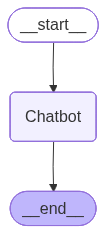

In [20]:
graph_compiled

In [21]:
def ask_question(state: State) -> State:

    print(f"\n-------> ENTERING ask_question:")

    print("What is your question?")

    return State(messages = [HumanMessage(input())])

In [22]:
def ask_another_question(state: State) -> State:

    print(f"\n-------> ENTERING ask_another_question:")

    print("Would you like to ask one more question (yes/no)?")

    return State(messages = [HumanMessage(input())])

In [66]:
def routing_function(state: State) -> str:
    # print(state["messages"])
    if not state["messages"]:
        return "__end__"
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "content") and last_msg.content.lower().strip() == "yes":
        return "ask_question"
    return "__end__"


In [67]:
graph = StateGraph(State)

In [68]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_conditional_edges(source = "ask_another_question",
                            path = routing_function)

In [69]:
graph_compiled = graph.compile()

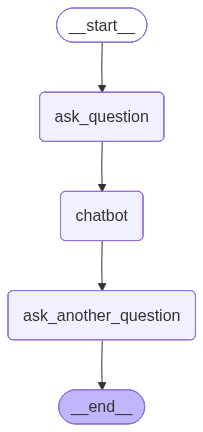

In [70]:
graph_compiled

In [71]:
print(graph_compiled.get_graph().draw_ascii())

      +-----------+      
      | __start__ |      
      +-----------+      
            *            
            *            
            *            
    +--------------+     
    | ask_question |     
    +--------------+     
            *            
            *            
            *            
      +---------+        
      | chatbot |        
      +---------+        
            *            
            *            
            *            
+----------------------+ 
| ask_another_question | 
+----------------------+ 
            *            
            *            
            *            
      +---------+        
      | __end__ |        
      +---------+        


In [73]:
graph_compiled.invoke(State(messages = []))


-------> ENTERING ask_question:
What is your question?
hi

-------> ENTERING chatbot:
================================== Ai Message ==================================

Hello! How can I help you today? 😊

-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?
yes
[HumanMessage(content='yes', additional_kwargs={}, response_metadata={})]

-------> ENTERING ask_question:
What is your question?
hi

-------> ENTERING chatbot:
================================== Ai Message ==================================

Hi! How can I help you today? 😊

-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?
no
[HumanMessage(content='no', additional_kwargs={}, response_metadata={})]


{'messages': [HumanMessage(content='no', additional_kwargs={}, response_metadata={})]}